Scanning for the most correlated pair...


[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  2 of 2 completed

✅ Selected Pair: MA & V (Correlation: 0.8711)
Backtesting with $10000 initial investment...


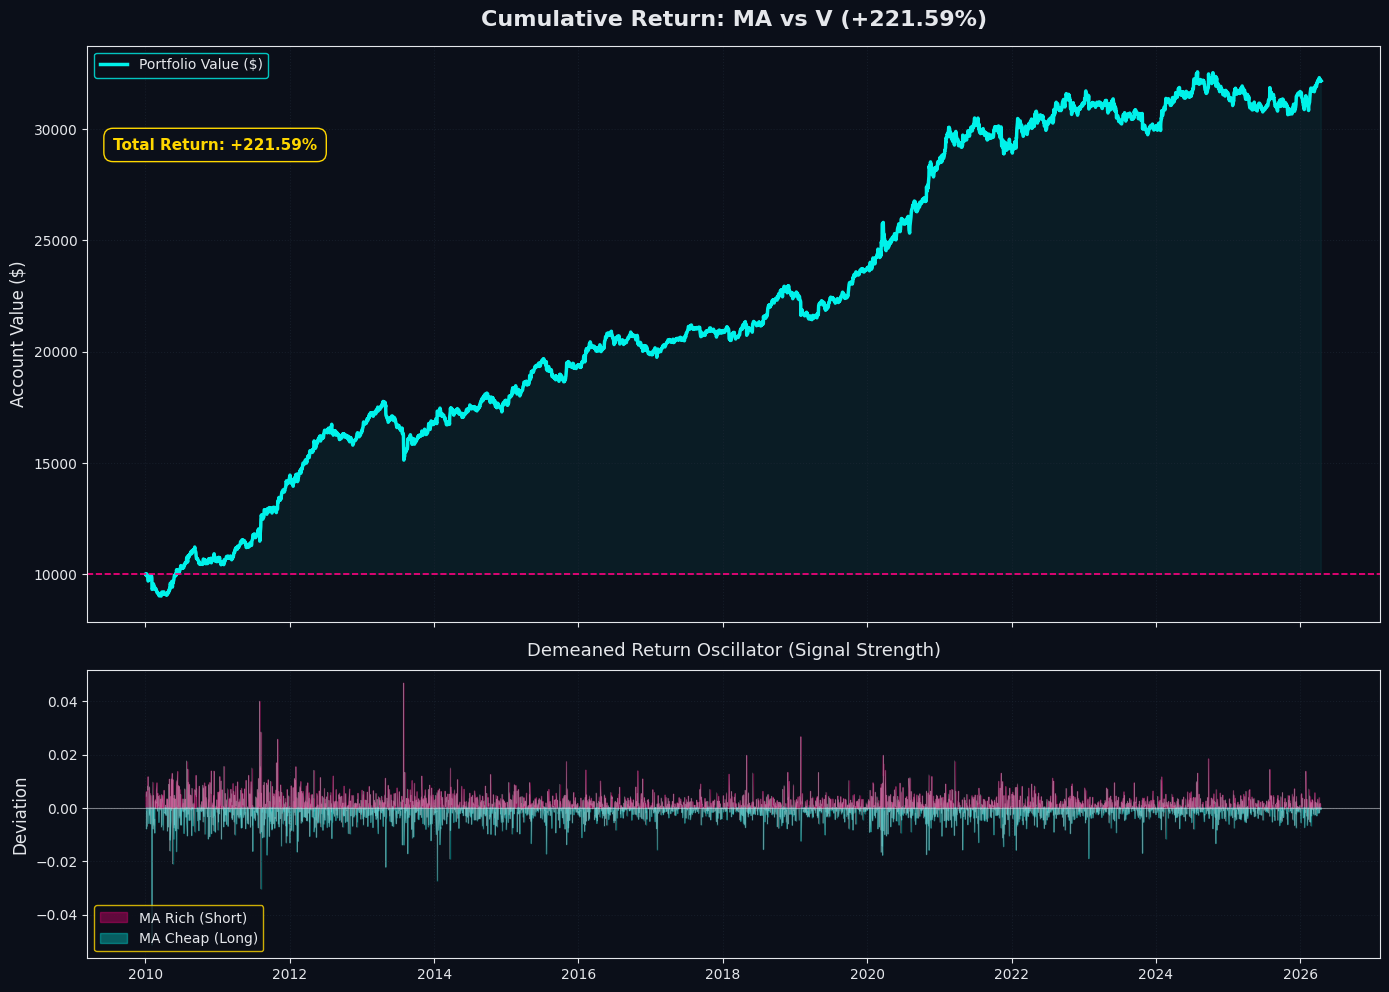

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration
initial_investment = 10000
# Representative Blue Chip list to avoid yfinance rate limits
sp500_tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'BRK-B', 'V', 'MA', 
    'JPM', 'BAC', 'WFC', 'GS', 'JNJ', 'PFE', 'ABBV', 'MRK', 'UNH', 'XOM', 
    'CVX', 'PG', 'KO', 'PEP', 'COST', 'WMT', 'HD', 'LOW', 'T', 'VZ'
]

# 2. Scanning Phase (Find Best Pair)
print("Scanning for the most correlated pair...")
scan_data = yf.download(sp500_tickers, start='2010-01-01', end='2026-12-31', auto_adjust=True)['Close']

if isinstance(scan_data.columns, pd.MultiIndex):
    scan_data.columns = scan_data.columns.get_level_values(0)

scan_returns = np.log(scan_data / scan_data.shift(1)).dropna()

corr_matrix = scan_returns.corr()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
sol = corr_matrix.where(mask).stack().sort_values(ascending=False)

ticker_A, ticker_B = sol.index[0]
print(f"✅ Selected Pair: {ticker_A} & {ticker_B} (Correlation: {sol.iloc[0]:.4f})")

# 3. Backtest Phase (2024 - Present)
print(f"Backtesting with ${initial_investment} initial investment...")
bt_data = yf.download([ticker_A, ticker_B], start='2010-01-01', end='2026-04-20', auto_adjust=True)['Close'].dropna()

if isinstance(bt_data.columns, pd.MultiIndex):
    bt_data.columns = bt_data.columns.get_level_values(0)

# Calculate Returns (Eq 285-286)
returns = np.log(bt_data / bt_data.shift(1))

# Demeaned Returns for Oscillator (Eq 287-289)
mean_return = returns.mean(axis=1)
demeaned_A = returns[ticker_A] - mean_return

# Trading Signals (Short if rich, Buy if cheap)
signal_A = -np.sign(demeaned_A.shift(1))
signal_B = -np.sign((-demeaned_A).shift(1)) 

# Strategy Return (Dollar Neutral: 0.5 weight each)
strategy_daily_ret = (signal_A * returns[ticker_A] * 0.5) + (signal_B * returns[ticker_B] * 0.5)

# Cumulative Return calculation
cum_return_pct = (1 + strategy_daily_ret.fillna(0)).cumprod() - 1
portfolio_value = initial_investment * (1 + cum_return_pct)

# --- AESTHETIC CONFIGURATION (CYBERPUNK ENGINE) ---
bg_color = '#0b0f19'      # Deep navy-black
grid_color = '#1f2937'    # Charcoal grid
cyan_neon = '#00f2ea'     # Long Accents / Asset Gains
magenta_neon = '#ff007f'  # Short Accents / Thresholds
yellow_neon = '#ffd700'   # Callouts & Metric Highlights
text_color = '#e5e7eb'    # Off-white text

plt.rcParams.update({
    'axes.facecolor': bg_color,
    'figure.facecolor': bg_color,
    'axes.edgecolor': text_color,
    'axes.labelcolor': text_color,
    'xtick.color': text_color,
    'ytick.color': text_color,
    'text.color': text_color,
    'grid.color': grid_color,
    'font.family': 'sans-serif'
})

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

# --- Top Chart: Cumulative Return ($ Value) ---
ax1.plot(portfolio_value, color=cyan_neon, lw=2.5, label='Portfolio Value ($)')
ax1.axhline(initial_investment, color=magenta_neon, lw=1.2, linestyle='--')

# Glow effect shading for the equity curve
ax1.fill_between(portfolio_value.index, initial_investment, portfolio_value, 
                 where=(portfolio_value >= initial_investment), color=cyan_neon, alpha=0.06)
ax1.fill_between(portfolio_value.index, initial_investment, portfolio_value, 
                 where=(portfolio_value < initial_investment), color=magenta_neon, alpha=0.06)

final_return_pct = cum_return_pct.iloc[-1] * 100
ax1.set_title(f'Cumulative Return: {ticker_A} vs {ticker_B} ({final_return_pct:+.2f}%)', 
              fontsize=16, fontweight='bold', y=1.02)
ax1.set_ylabel('Account Value ($)', fontsize=12)

leg1 = ax1.legend(loc='upper left', frameon=True, facecolor=bg_color, edgecolor=cyan_neon)
plt.setp(leg1.get_texts(), color=text_color)
ax1.grid(True, linestyle=':', alpha=0.5)

# Highlighting total return using the portfolio layout custom textbox
ax1.text(0.02, 0.82, f'Total Return: {final_return_pct:+.2f}%', transform=ax1.transAxes, 
         color=yellow_neon, fontweight='bold', fontsize=11,
         bbox=dict(facecolor=bg_color, edgecolor=yellow_neon, boxstyle='round,pad=0.6'))

# --- Bottom Chart: The Mispricing Oscillator ---
ax2.fill_between(demeaned_A.index, demeaned_A, 0, where=(demeaned_A >= 0), 
                 color=magenta_neon, alpha=0.35, label=f'{ticker_A} Rich (Short)')
ax2.fill_between(demeaned_A.index, demeaned_A, 0, where=(demeaned_A < 0), 
                 color=cyan_neon, alpha=0.35, label=f'{ticker_A} Cheap (Long)')

# Thin tracking line for visibility
ax2.plot(demeaned_A, color=text_color, lw=0.4, alpha=0.4)
ax2.axhline(0, color=text_color, lw=0.8, alpha=0.5)

ax2.set_title('Demeaned Return Oscillator (Signal Strength)', fontsize=13, pad=10)
ax2.set_ylabel('Deviation', fontsize=12)

leg2 = ax2.legend(loc='lower left', frameon=True, facecolor=bg_color, edgecolor=yellow_neon)
plt.setp(leg2.get_texts(), color=text_color)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()